Modern networks generate massive volumes of traffic every second. Monitoring traffic in real time is critical for:

- Network security monitoring
- DDoS detection
- Network performance analysis
- Traffic engineering

However, storing all packets is expensive. Modern systems use **compact probabilistic data structures called sketches** to estimate flow statistics efficiently.

## Objective

This prototype demonstrates how sketch-based algorithms can monitor network traffic streams and detect abnormal traffic bursts.

Pipeline:

Traffic Stream → Flow Extraction → Count-Min Sketch → Heavy Hitter Detection → Anomaly Detection → Visualization

In [9]:
!pip install numpy pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import hashlib
from collections import defaultdict

Simulate Network Traffic

In [10]:
def generate_ip():
    return ".".join(str(random.randint(0,255)) for _ in range(4))

traffic = []

for i in range(2000):

    # simulate normal traffic
    src = generate_ip()
    dst = generate_ip()

    # inject burst attack traffic
    if random.random() < 0.05:
        src = "192.168.1.1"
        dst = "10.0.0.1"

    packet = {
        "source": src,
        "destination": dst,
        "size": random.randint(40,1500),
        "timestamp": i
    }

    traffic.append(packet)

df = pd.DataFrame(traffic)

df.head()

,source,destination,size,timestamp
0,90.153.175.164,100.67.232.43,887,0
1,15.111.188.68,4.145.166.229,996,1
2,211.102.101.239,104.165.30.197,700,2
3,46.21.243.196,109.116.250.29,1200,3
4,155.21.127.223,97.255.85.20,1197,4


Count-Min Sketch Implementation

In [11]:
class CountMinSketch:

    def __init__(self, width, depth):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width))

    def hash(self, item, seed):
        return int(hashlib.md5((item + str(seed)).encode()).hexdigest(),16) % self.width

    def add(self, item):
        for i in range(self.depth):
            index = self.hash(item, i)
            self.table[i][index] += 1

    def estimate(self, item):
        estimates = []

        for i in range(self.depth):
            index = self.hash(item, i)
            estimates.append(self.table[i][index])

        return min(estimates)

In [12]:
cms = CountMinSketch(width=200, depth=5)

Process Traffic Stream

In [13]:
flow_counts = []

for _, row in df.iterrows():

    flow = row["source"] + "-" + row["destination"]

    cms.add(flow)

    estimate = cms.estimate(flow)

    flow_counts.append(estimate)

Heavy Hitter Detection

In [14]:
threshold = 20

heavy_hitters = []

for i,count in enumerate(flow_counts):

    if count > threshold:
        heavy_hitters.append(i)

print("Detected heavy hitter packets:", heavy_hitters[:20])

Detected heavy hitter packets: [364, 375, 410, 420, 434, 454, 459, 472, 474, 479, 480, 483, 502, 509, 531, 532, 566, 571, 675, 681]


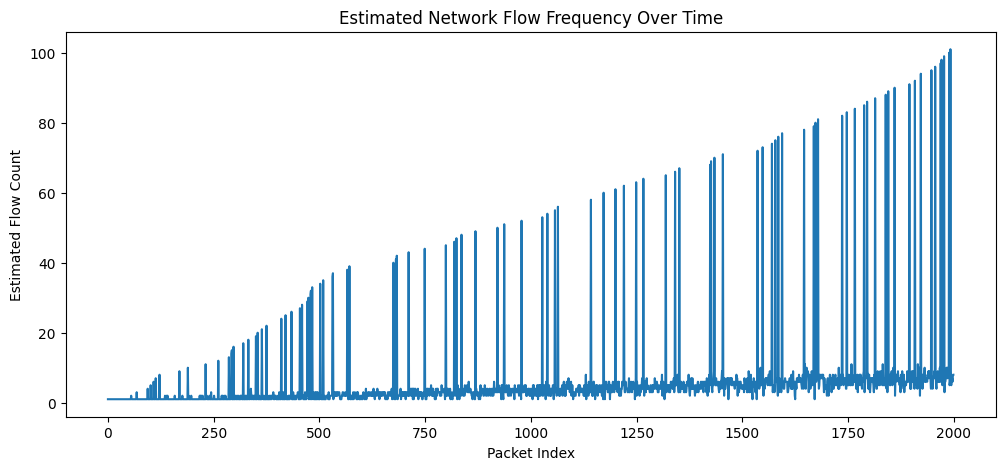

In [15]:
plt.figure(figsize=(12,5))

plt.plot(flow_counts)

plt.title("Estimated Network Flow Frequency Over Time")

plt.xlabel("Packet Index")

plt.ylabel("Estimated Flow Count")

plt.show()

Burst Detection

In [16]:
window = 50
burst_points = []

for i in range(len(flow_counts)-window):

    avg = np.mean(flow_counts[i:i+window])

    if avg > 10:
        burst_points.append(i)

print("Detected burst windows:", burst_points[:10])

Detected burst windows: [1405, 1406, 1407, 1408, 1409, 1410, 1411, 1412, 1413, 1414]


Visualize Anomalies

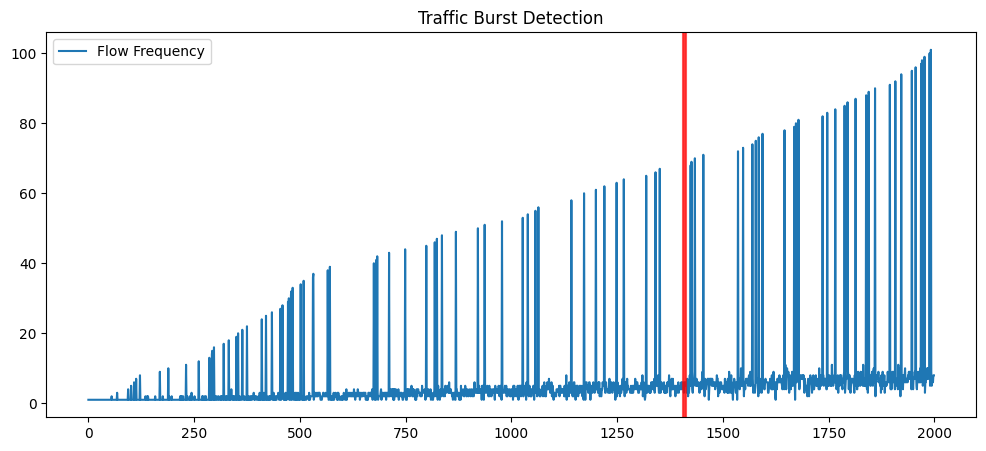

In [17]:
plt.figure(figsize=(12,5))

plt.plot(flow_counts, label="Flow Frequency")

for p in burst_points[:10]:
    plt.axvline(p, color='red', alpha=0.3)

plt.legend()

plt.title("Traffic Burst Detection")

plt.show()

## Conclusion

This prototype demonstrates how compact sketch data structures can monitor streaming network traffic efficiently.

Key observations:

- Sketch-based methods allow fast frequency estimation
- Traffic bursts can indicate abnormal behavior
- Such techniques are widely used in modern network monitoring systems

Future work may include applying these techniques to real network traffic datasets and integrating machine learning for advanced anomaly detection.